# Customer Churn Prediction - Complete Analysis Notebook

## Telco Customer Churn Dataset Analysis

This notebook contains:
1. **Exploratory Data Analysis (EDA)** - Data exploration and visualization
2. **Model Training** - Training and evaluation of 4 ML models
3. **Performance Analysis** - Comparative analysis and recommendations

## Table of Contents

### Part 1: Exploratory Data Analysis
- Data Loading and Overview
- Statistical Summary
- Data Visualization
- Correlation Analysis

### Part 2: Model Training and Evaluation
- Setup and Imports
- Data Preprocessing
- Decision Tree Model
- Naive Bayes Model
- Random Forest Model (Chosen Algorithm)
- SVM Model

### Part 3: Performance Analysis
- Model Comparison
- Test vs Unseen Evaluation
- Visualization and Reports
- Executive Summary and Recommendations

# PART 1: EXPLORATORY DATA ANALYSIS

## 1.1 Data Loading and Overview

In [1]:
# Import libraries for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette('husl')

# Define paths
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
data_path = str(project_root / 'data' / 'processed' / 'Cleaned_Telco_Customer.csv')
results_dir = str(project_root / 'results')

# Create results directory if it doesn't exist
os.makedirs(results_dir, exist_ok=True)
print(f'Results directory: {results_dir}')

# Load the dataset
print('Loading Telco Customer Churn dataset...')
df = pd.read_csv(data_path)

# Basic information
print(f'Dataset Shape: {df.shape}')
print(f'\nColumn Names and Data Types:')
print(df.dtypes)
print(f'\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplicated Rows: {df.duplicated().sum()}')

Results directory: c:\Users\vigil\New folder\MidtermSummativeAct\results
Loading Telco Customer Churn dataset...
Dataset Shape: (7043, 20)

Column Names and Data Types:
gender( m = 1, f = 0)                                               int64
SeniorCitizen (Y=1, N=0)                                            int64
Partner (Y=1, N=0)                                                  int64
Dependents (Y=1, N=0)                                               int64
tenure                                                              int64
PhoneService (Y=1, N=0)                                             int64
MultipleLines (Y=1, N=0 , NS = 2)                                   int64
InternetService ( N = 0, DSL = 1, FBR OPT. = 2                      int64
OnlineSecurity ( 0 internet serv. =2)                               int64
OnlineBackup ( 0 internet serv. =2)                                 int64
DeviceProtection ( 0 internet serv. =2)                             int64
TechSupport ( 0 i

## 1.2 Statistical Summary

In [2]:
# Statistical summary for numerical columns
print('Numerical Columns Summary:')
print(df.describe())

# Target variable distribution
print('\nTarget Variable (Churn) Distribution:')
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f'No Churn (0): {churn_counts[0]} ({churn_pct[0]:.2f}%)')
print(f'Churn (1): {churn_counts[1]} ({churn_pct[1]:.2f}%)')

Numerical Columns Summary:
       gender( m = 1, f = 0)  SeniorCitizen (Y=1, N=0)  Partner (Y=1, N=0)  \
count            7043.000000               7043.000000         7043.000000   
mean                0.504756                  0.162147            0.483033   
std                 0.500013                  0.368612            0.499748   
min                 0.000000                  0.000000            0.000000   
25%                 0.000000                  0.000000            0.000000   
50%                 1.000000                  0.000000            0.000000   
75%                 1.000000                  0.000000            1.000000   
max                 1.000000                  1.000000            1.000000   

       Dependents (Y=1, N=0)       tenure  PhoneService (Y=1, N=0)  \
count            7043.000000  7043.000000              7043.000000   
mean                0.299588    32.371149                 0.903166   
std                 0.458110    24.559481                 0.

## 1.3 Data Visualization

EDA overview saved to: c:\Users\vigil\New folder\MidtermSummativeAct\results\eda_overview.png


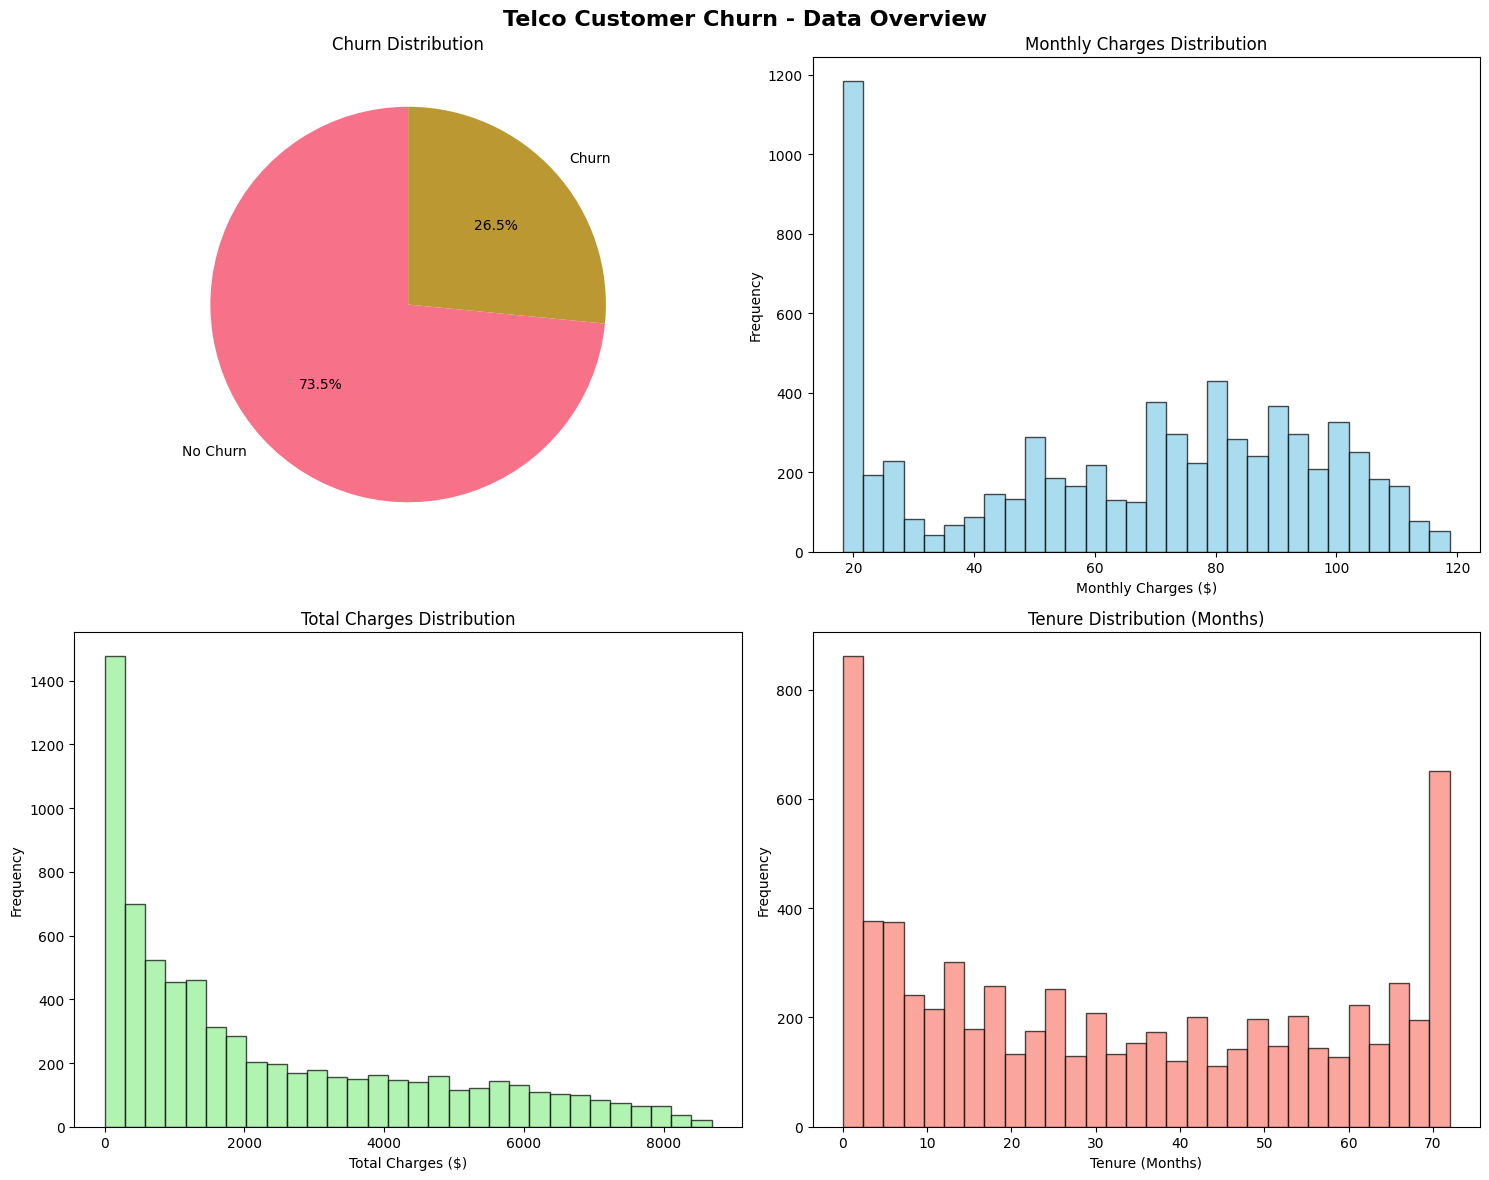

In [3]:
# Churn distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Telco Customer Churn - Data Overview', fontsize=16, fontweight='bold')

# Churn distribution
axes[0, 0].pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Churn Distribution')

# Monthly charges distribution
axes[0, 1].hist(df['MonthlyCharges'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Monthly Charges Distribution')
axes[0, 1].set_xlabel('Monthly Charges ($)')
axes[0, 1].set_ylabel('Frequency')

# Total charges distribution
axes[1, 0].hist(df['TotalCharges'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Total Charges Distribution')
axes[1, 0].set_xlabel('Total Charges ($)')
axes[1, 0].set_ylabel('Frequency')

# Tenure distribution
axes[1, 1].hist(df['tenure'], bins=30, alpha=0.7, color='salmon', edgecolor='black')
axes[1, 1].set_title('Tenure Distribution (Months)')
axes[1, 1].set_xlabel('Tenure (Months)')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
eda_path = os.path.join(results_dir, 'eda_overview.png')
plt.savefig(eda_path, dpi=300, bbox_inches='tight')
print(f'EDA overview saved to: {eda_path}')
plt.show()

## 1.4 Correlation Analysis

Correlation matrix saved to: c:\Users\vigil\New folder\MidtermSummativeAct\results\correlation_matrix.png


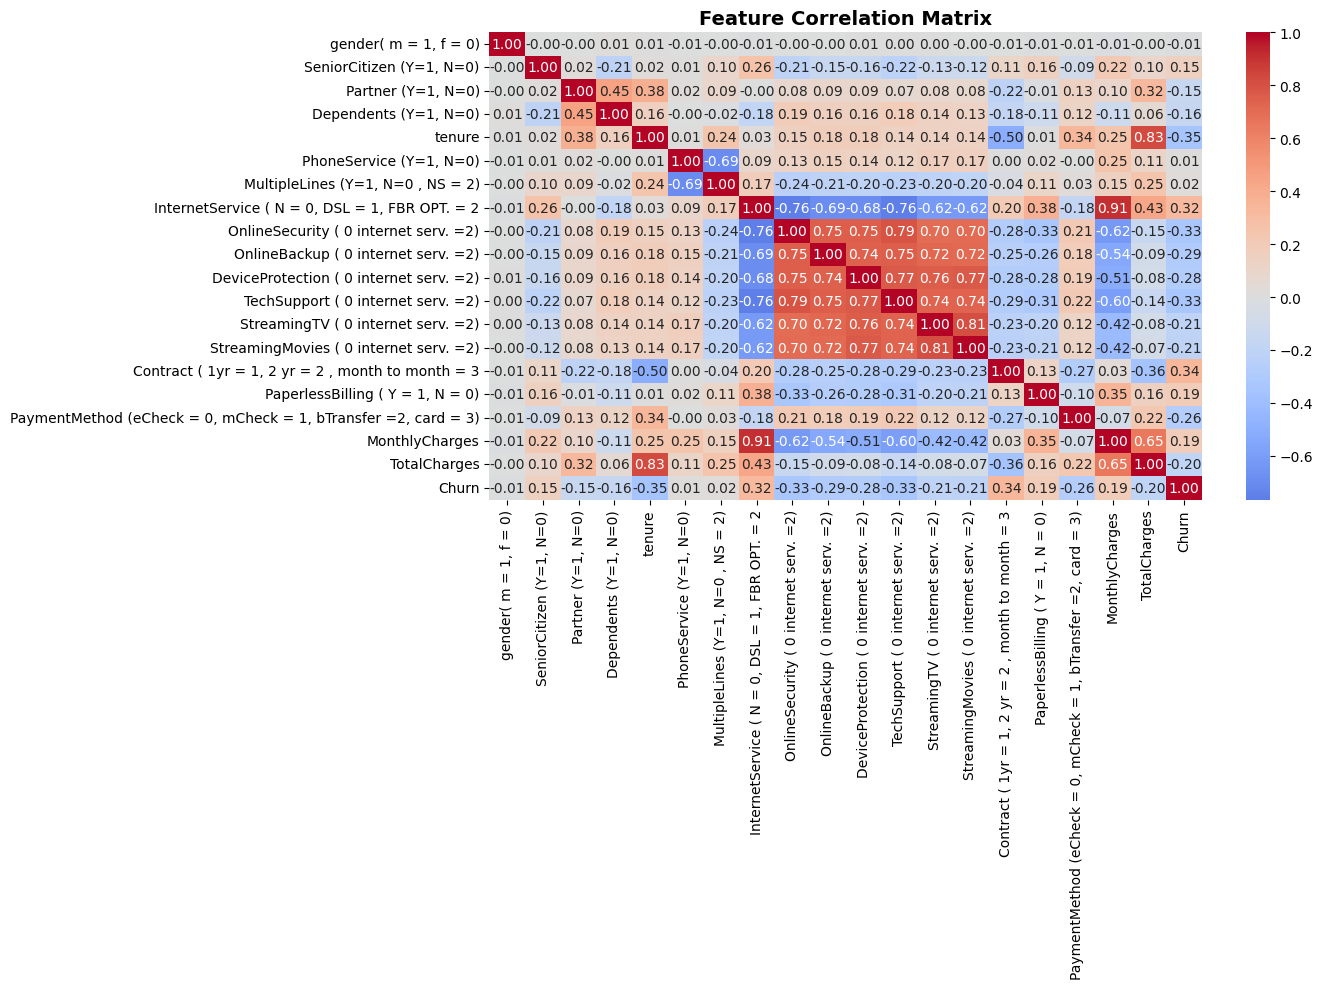


Top 10 Features Correlated with Churn:
tenure                                                            0.352229
Contract ( 1yr = 1, 2 yr = 2 , month to month = 3                 0.341504
OnlineSecurity ( 0 internet serv. =2)                             0.332819
TechSupport ( 0 internet serv. =2)                                0.329852
InternetService ( N = 0, DSL = 1, FBR OPT. = 2                    0.316846
OnlineBackup ( 0 internet serv. =2)                               0.291449
DeviceProtection ( 0 internet serv. =2)                           0.281465
PaymentMethod (eCheck = 0, mCheck = 1, bTransfer =2, card = 3)    0.262818
StreamingMovies ( 0 internet serv. =2)                            0.207256
StreamingTV ( 0 internet serv. =2)                                0.205742
Name: Churn, dtype: float64


In [4]:
# Correlation matrix
import os

plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
corr_path = os.path.join(results_dir, 'correlation_matrix.png')
plt.savefig(corr_path, dpi=300, bbox_inches='tight')
print(f'Correlation matrix saved to: {corr_path}')
plt.show()

# Features most correlated with Churn
print('\nTop 10 Features Correlated with Churn:')
churn_corr = correlation_matrix['Churn'].abs().sort_values(ascending=False)[1:11]
print(churn_corr)

# PART 2: MODEL TRAINING AND EVALUATION

## 2.1 Setup and Imports

In [5]:
# Import required libraries for model training
import sys

# Add src directory to path
sys.path.append(str(project_root / 'src'))

from models.decision_tree import train_decision_tree, evaluate_decision_tree, extract_decision_rules, visualize_decision_tree
from models.naive_bayes import train_naive_bayes, evaluate_naive_bayes
from models.random_forest import train_chosen_algorithm, evaluate_chosen_algorithm
from models.svm import train_svm, evaluate_svm, load_cleaned_data
from sklearn.model_selection import train_test_split
from evaluation import compute_all_metrics

print('All models imported successfully!')

All models imported successfully!


## 2.2 Data Preprocessing

In [6]:
# Prepare features and target
X = df.drop('Churn', axis=1)
y = df['Churn']
feature_names = X.columns.tolist()

# Apply strict data splitting protocol: 90% main, 10% unseen; then 80/20 split
print('Applying strict data splitting protocol (90/10, then 80/20)...')
X_main, X_unseen, y_main, y_unseen = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X_main, y_main, test_size=0.20, random_state=42, stratify=y_main)

print(f'Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})')
print(f'Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})')
print(f'Unseen validation: {X_unseen.shape[0]} samples ({X_unseen.shape[0]/len(X):.1%})')
print(f'Total: {len(X)} samples')

Applying strict data splitting protocol (90/10, then 80/20)...
Training set: 5070 samples (72.0%)
Test set: 1268 samples (18.0%)
Unseen validation: 705 samples (10.0%)
Total: 7043 samples


## 2.3 Decision Tree Model

In [7]:
# Train Decision Tree - STANDALONE Rule-based classifier
# Note: No performance metrics - Decision Tree is evaluated on rules/patterns only
import os

print('Training Decision Tree...')
dt_model = train_decision_tree(X_train, y_train, max_depth=5)
dt_rules_path = os.path.join(results_dir, 'decision_tree_rules.txt')
dt_viz_path = os.path.join(results_dir, 'decision_tree_visualization.png')
dt_rules = extract_decision_rules(dt_model, feature_names, dt_rules_path)
visualize_decision_tree(dt_model, feature_names, dt_viz_path)

print('\n' + '='*70)
print('DECISION TREE - RULE-BASED CLASSIFIER')
print('='*70)
print('Status: Trained and rules extracted successfully')
print('Focus: Decision rules and pattern analysis (no performance metrics)')
print('Files saved:')
print(f'  - Rules: {dt_rules_path}')
print(f'  - Visualization: results/decision_tree_visualization.png')
print('='*70)

Training Decision Tree...

--- Extracted Decision Tree Rules ---
|--- Contract ( 1yr = 1, 2 yr = 2 , month to month = 3 <= 2.50
|   |--- OnlineSecurity ( 0 internet serv. =2) <= 0.50
|   |   |--- Contract ( 1yr = 1, 2 yr = 2 , month to month = 3 <= 1.50
|   |   |   |--- MonthlyCharges <= 99.92
|   |   |   |   |--- MonthlyCharges <= 24.48
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- MonthlyCharges >  24.48
|   |   |   |   |   |--- class: 0
|   |   |   |--- MonthlyCharges >  99.92
|   |   |   |   |--- MonthlyCharges <= 100.10
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- MonthlyCharges >  100.10
|   |   |   |   |   |--- class: 0
|   |   |--- Contract ( 1yr = 1, 2 yr = 2 , month to month = 3 >  1.50
|   |   |   |--- TotalCharges <= 7304.98
|   |   |   |   |--- TechSupport ( 0 internet serv. =2) <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- TechSupport ( 0 internet serv. =2) >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- TotalCharges >  7304.

## 2.4 Naive Bayes Model

In [8]:
# Train Naive Bayes
from models.naive_bayes import compute_metrics as nb_metrics
from sklearn.model_selection import cross_val_predict, StratifiedKFold
import numpy as np

print('Training Naive Bayes...')
nb_model = train_naive_bayes(X_train, y_train)

# Evaluate with 10-fold CV
print('\nNaive Bayes 10-Fold CV Results:')
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(nb_model, X_train, y_train, cv=splitter)
y_prob_cv = cross_val_predict(nb_model, X_train, y_train, cv=splitter, method='predict_proba')[:, 1]
nb_cv_results = nb_metrics(y_train, y_pred_cv, y_prob_cv)

# Display in tabular format
nb_df = pd.DataFrame([nb_cv_results])
print('\n' + '='*70)
print('NAIVE BAYES - 10-FOLD CROSS-VALIDATION RESULTS')
print('='*70)
print(nb_df.round(4).to_string(index=False))
print('='*70)

Training Naive Bayes...

Naive Bayes 10-Fold CV Results:

NAIVE BAYES - 10-FOLD CROSS-VALIDATION RESULTS
           Confusion Matrix  Accuracy  Precision  Recall  F1-score  Specificity  ROC-AUC
[[2584, 1141], [263, 1082]]    0.7231     0.4867  0.8045    0.6065       0.6937   0.8088


## 2.5 Random Forest Model (Chosen Algorithm)

In [9]:
# Train Random Forest
from models.random_forest import compute_metrics as rf_metrics
from sklearn.model_selection import cross_val_predict, StratifiedKFold

print('Training Random Forest (Chosen Algorithm)...')
rf_model = train_chosen_algorithm(X_train, y_train)

# Evaluate with 10-fold CV
print('\nRandom Forest 10-Fold CV Results:')
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(rf_model, X_main, y_main, cv=splitter)
y_prob_cv = cross_val_predict(rf_model, X_main, y_main, cv=splitter, method='predict_proba')[:, 1]
rf_cv_results = rf_metrics(y_main, y_pred_cv, y_prob_cv)

# Display in tabular format
rf_df = pd.DataFrame([rf_cv_results])
print('\n' + '='*70)
print('RANDOM FOREST - 10-FOLD CROSS-VALIDATION RESULTS')
print('='*70)
print(rf_df.round(4).to_string(index=False))
print('='*70)

Training Random Forest (Chosen Algorithm)...

Random Forest 10-Fold CV Results:

RANDOM FOREST - 10-FOLD CROSS-VALIDATION RESULTS
         Confusion Matrix  Accuracy  Precision  Recall  F1-score  Specificity  ROC-AUC
[[4175, 481], [870, 812]]    0.7868      0.628  0.4828    0.5459       0.8967   0.8233


## 2.6 SVM Model

In [10]:
# Train SVM with feature scaling
from models.svm import compute_metrics as svm_metrics
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler

print('Training SVM...')
X_svm, y_svm = load_cleaned_data(data_path)
X_svm_main, X_svm_unseen, y_svm_main, y_svm_unseen = train_test_split(
    X_svm, y_svm, test_size=0.10, random_state=42, stratify=y_svm
)
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    X_svm_main, y_svm_main, test_size=0.20, random_state=42, stratify=y_svm_main
)

# Scale features
scaler = StandardScaler()
X_svm_train_scaled = scaler.fit_transform(X_svm_train)

svm_model = train_svm(X_svm_train_scaled, y_svm_train)

# Evaluate with 10-fold CV
print('\nSVM 10-Fold CV Results:')
splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(svm_model, X_svm_train_scaled, y_svm_train, cv=splitter)
y_prob_cv = cross_val_predict(svm_model, X_svm_train_scaled, y_svm_train, cv=splitter, method='predict_proba')[:, 1]
svm_cv_results = svm_metrics(y_svm_train, y_pred_cv, y_prob_cv)

# Display in tabular format
svm_df = pd.DataFrame([svm_cv_results])
print('\n' + '='*70)
print('SVM - 10-FOLD CROSS-VALIDATION RESULTS')
print('='*70)
print(svm_df.round(4).to_string(index=False))
print('='*70)

Training SVM...

SVM 10-Fold CV Results:

SVM - 10-FOLD CROSS-VALIDATION RESULTS
          Confusion Matrix  Accuracy  Precision  Recall  F1-score  Specificity  ROC-AUC
[[2741, 984], [309, 1036]]     0.745     0.5129  0.7703    0.6158       0.7358   0.8236


# PART 3: PERFORMANCE ANALYSIS

## 3.1 Model Comparison - 10-Fold Cross-Validation Results

In [11]:
# Compile CV results for 3 models (Decision Tree is standalone, not included in comparison)
models_data = []
model_names = ['Naive Bayes', 'Random Forest', 'SVM']
cv_results = [nb_cv_results, rf_cv_results, svm_cv_results]

for name, results in zip(model_names, cv_results):
    if isinstance(results, dict):
        models_data.append({
            'Model': name,
            'Accuracy': results.get('Accuracy', 0),
            'Precision': results.get('Precision', 0),
            'Recall': results.get('Recall', 0),
            'F1-score': results.get('F1-score', 0),
            'Specificity': results.get('Specificity', 0),
            'ROC-AUC': results.get('ROC-AUC', 0)
        })

# Create comparison table
cv_comparison_df = pd.DataFrame(models_data)

# Display formatted comparison table
print('\n' + '='*90)
print('10-FOLD CROSS-VALIDATION RESULTS COMPARISON - 3 CLASSIFICATION ALGORITHMS')
print('(Note: Decision Tree analyzed separately as rule-based classifier)')
print('='*90)
print(cv_comparison_df.round(4).to_string(index=False))
print('='*90)


10-FOLD CROSS-VALIDATION RESULTS COMPARISON - 3 CLASSIFICATION ALGORITHMS
(Note: Decision Tree analyzed separately as rule-based classifier)
        Model  Accuracy  Precision  Recall  F1-score  Specificity  ROC-AUC
  Naive Bayes    0.7231     0.4867  0.8045    0.6065       0.6937   0.8088
Random Forest    0.7868     0.6280  0.4828    0.5459       0.8967   0.8233
          SVM    0.7450     0.5129  0.7703    0.6158       0.7358   0.8236


## 3.2 Performance Visualization

In [12]:
# Reload SVM module with balanced class weights and re-train
import importlib
import models.svm as svm_module
importlib.reload(svm_module)
from models.svm import train_svm, evaluate_svm, load_cleaned_data
from sklearn.preprocessing import StandardScaler

# Re-train SVM with updated class weights
print('Training SVM with balanced class weights...')
X_svm, y_svm = load_cleaned_data(data_path)
X_svm_main, X_svm_unseen, y_svm_main, y_svm_unseen = train_test_split(
    X_svm, y_svm, test_size=0.10, random_state=42, stratify=y_svm
)
X_svm_train, X_svm_test, y_svm_train, y_svm_test = train_test_split(
    X_svm_main, y_svm_main, test_size=0.20, random_state=42, stratify=y_svm_main
)

# Scale features
scaler = StandardScaler()
X_svm_train_scaled = scaler.fit_transform(X_svm_train)
X_svm_test_scaled = scaler.transform(X_svm_test)
X_svm_unseen_scaled = scaler.transform(X_unseen)

# Train and evaluate
svm_model = train_svm(X_svm_train_scaled, y_svm_train)
print('\nSVM 10-Fold CV Results:')
svm_cv_results = evaluate_svm(svm_model, X_svm_train_scaled, y_svm_train, cv=10)

# Update SVM results in models_data (find and replace)
for i, name in enumerate(model_names):
    if name == 'SVM':
        models_data[i] = {
            'Model': 'SVM',
            'Accuracy': svm_cv_results.get('Accuracy', 0),
            'Precision': svm_cv_results.get('Precision', 0),
            'Recall': svm_cv_results.get('Recall', 0),
            'F1-score': svm_cv_results.get('F1-score', 0),
            'Specificity': svm_cv_results.get('Specificity', 0),
            'ROC-AUC': svm_cv_results.get('ROC-AUC', 0)
        }
        break

print('\nUpdated SVM results:', models_data)

Training SVM with balanced class weights...

SVM 10-Fold CV Results:

Evaluating SVM with 10-fold CV...
Applying StratifiedKFold with 10 folds...
Confusion Matrix:
[[2741  984]
 [ 309 1036]]
Accuracy: 0.7450
Precision: 0.5129
Recall: 0.7703
F1-score: 0.6158
Specificity: 0.7358
ROC-AUC: 0.8236
CV Folds: 10.0000
Fold Accuracies: [0.7456, 0.7791, 0.7475, 0.7811, 0.7535, 0.716, 0.7061, 0.7377, 0.7357, 0.7475]
Fold Accuracy Mean: 0.7450
Fold Accuracy Std: 0.0225

Updated SVM results: [{'Model': 'Naive Bayes', 'Accuracy': 0.7230769230769231, 'Precision': 0.48672964462438145, 'Recall': 0.8044609665427509, 'F1-score': 0.6065022421524664, 'Specificity': np.float64(0.6936912751677853), 'ROC-AUC': 0.8088030737756045}, {'Model': 'Random Forest', 'Accuracy': 0.7868412748501105, 'Precision': 0.6279969064191802, 'Recall': 0.4827586206896552, 'F1-score': 0.5458823529411765, 'Specificity': np.float64(0.896692439862543), 'ROC-AUC': 0.8232945688327183}, {'Model': 'SVM', 'Accuracy': 0.7449704142011835, 'P

In [ ]:
## 3.2b Confusion Matrix Heatmaps per Model
from sklearn.metrics import confusion_matrix
import numpy as np

# Get predictions for test set for each model
models_for_viz = {
    'Naive Bayes': (nb_model.predict(X_test), nb_model.predict_proba(X_test)[:, 1]),
    'Random Forest': (rf_model.predict(X_test), rf_model.predict_proba(X_test)[:, 1]),
    'SVM': (svm_model.predict(X_svm_test), svm_model.predict_proba(X_svm_test)[:, 1])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrix Heatmaps - Test Set Predictions', fontsize=14, fontweight='bold')

for idx, (model_name, (y_pred, _)) in enumerate(models_for_viz.items()):
    if model_name == 'SVM':
        cm = confusion_matrix(y_svm_test, y_pred)
    else:
        cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    axes[idx].set_title(f'{model_name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
cm_path = os.path.join(results_dir, 'confusion_matrix_heatmaps.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f'Confusion Matrix heatmaps saved to: {cm_path}')
plt.show()

print('\nConfusion Matrices (Test Set):')
for model_name, (y_pred, _) in models_for_viz.items():
    if model_name == 'SVM':
        cm = confusion_matrix(y_svm_test, y_pred)
    else:
        cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f'{model_name}: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

In [ ]:
## 3.2c ROC Curves per Model
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors = ['blue', 'green', 'red']
for idx, (model_name, (y_pred, y_prob)) in enumerate(models_for_viz.items()):
    if model_name == 'SVM':
        y_true = y_svm_test
    else:
        y_true = y_test
    
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=colors[idx], lw=2, label=f'{model_name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Test Set Predictions', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
roc_path = os.path.join(results_dir, 'roc_curves_per_model.png')
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f'ROC Curves saved to: {roc_path}')
plt.show()

Comprehensive comparison saved to: c:\Users\vigil\New folder\MidtermSummativeAct\results\all_models_comparison.png


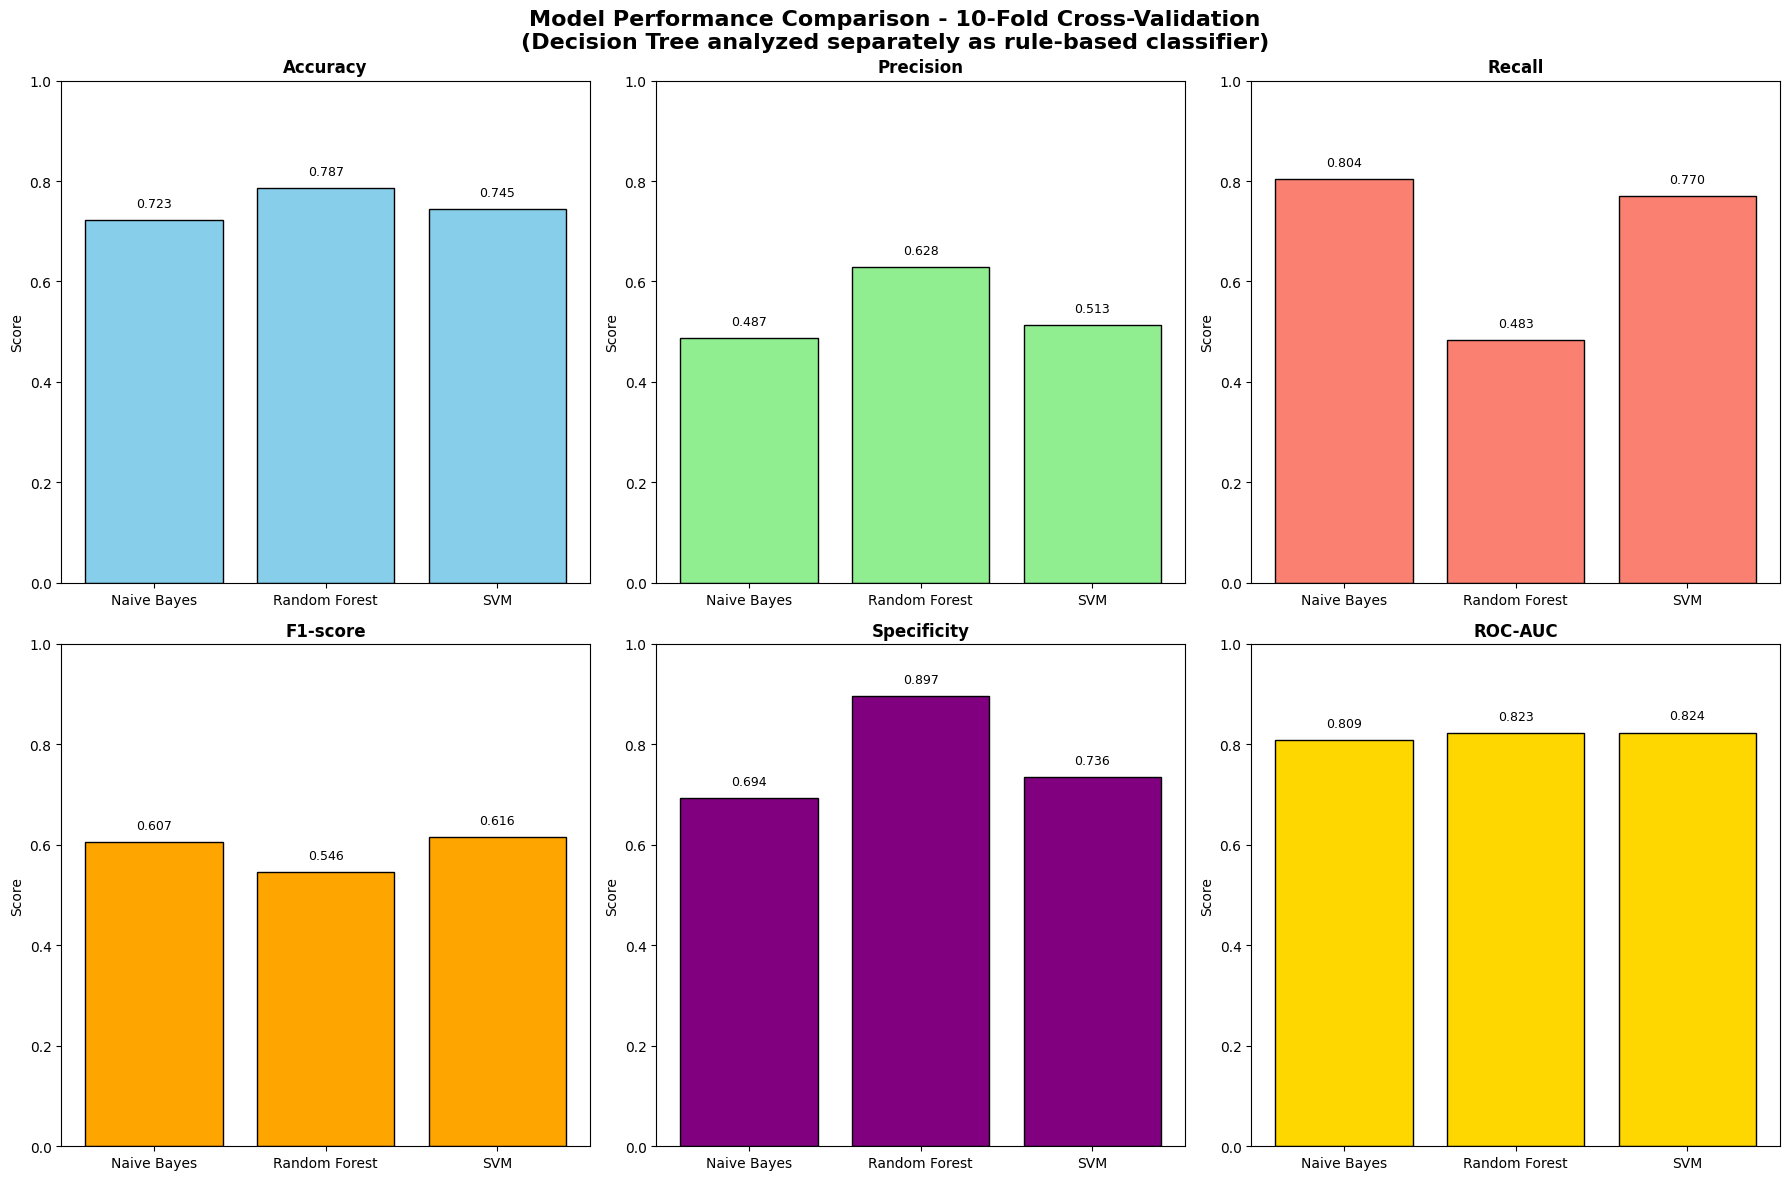

In [ ]:
# Create comprehensive comparison visualization - 3 ALGORITHMS ONLY
import os

# Use only 3 models (exclude Decision Tree from comparison)
comparison_model_names = ['Naive Bayes', 'Random Forest', 'SVM']
comparison_models_data = models_data

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Model Performance Comparison - 10-Fold Cross-Validation\n(Decision Tree analyzed separately as rule-based classifier)', 
             fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'Specificity', 'ROC-AUC']
colors = ['skyblue', 'lightgreen', 'salmon', 'orange', 'purple', 'gold']

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    row, col = idx // 3, idx % 3
    values = [m[metric] for m in comparison_models_data]
    axes[row, col].bar(comparison_model_names, values, color=color, edgecolor='black')
    axes[row, col].set_title(metric, fontweight='bold', fontsize=12)
    axes[row, col].set_ylim(0, 1)
    axes[row, col].set_ylabel('Score')
    for i, v in enumerate(values):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
comparison_path = os.path.join(results_dir, 'all_models_comparison.png')
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
print(f'Comparison bar chart saved to: {comparison_path}')
plt.show()

## 3.3 Final Test vs Unseen Data Evaluation

In [14]:
# Final evaluation - 3 CLASSIFICATION ALGORITHMS ONLY
# Decision Tree is validated separately (standalone, not in comparison)

# Validate Decision Tree on unseen data (standalone - NOT in comparison table)
print('=' * 80)
print('DECISION TREE - UNSEEN DATA VALIDATION (Standalone)')
print('=' * 80)
dt_test = compute_all_metrics(y_test, dt_model.predict(X_test), 
                               dt_model.predict_proba(X_test)[:, 1])
dt_unseen = compute_all_metrics(y_unseen, dt_model.predict(X_unseen), 
                                 dt_model.predict_proba(X_unseen)[:, 1])
print(f"Test Set - Accuracy: {dt_test['Accuracy']:.4f}, ROC-AUC: {dt_test['ROC-AUC']:.4f}")
print(f"Unseen Set - Accuracy: {dt_unseen['Accuracy']:.4f}, ROC-AUC: {dt_unseen['ROC-AUC']:.4f}")
print(f"Generalization Gap: {dt_test['Accuracy'] - dt_unseen['Accuracy']:.4f}")
print('Note: Decision Tree validated separately as rule-based classifier')
print('=' * 80)
print()

# Compare 3 classification algorithms (Naive Bayes, Random Forest, SVM)
final_results = {}

# Naive Bayes
nb_test = compute_all_metrics(y_test, nb_model.predict(X_test), 
                               nb_model.predict_proba(X_test)[:, 1])
nb_unseen = compute_all_metrics(y_unseen, nb_model.predict(X_unseen), 
                                 nb_model.predict_proba(X_unseen)[:, 1])
final_results['Naive Bayes'] = {'test': nb_test, 'unseen': nb_unseen}

# Random Forest
rf_test = compute_all_metrics(y_test, rf_model.predict(X_test), 
                               rf_model.predict_proba(X_test)[:, 1])
rf_unseen = compute_all_metrics(y_unseen, rf_model.predict(X_unseen), 
                                 rf_model.predict_proba(X_unseen)[:, 1])
final_results['Random Forest'] = {'test': rf_test, 'unseen': rf_unseen}

# SVM
svm_test = compute_all_metrics(y_svm_test, svm_model.predict(X_svm_test), 
                                svm_model.predict_proba(X_svm_test)[:, 1])
svm_unseen = compute_all_metrics(y_svm_unseen, svm_model.predict(X_svm_unseen), 
                                  svm_model.predict_proba(X_svm_unseen)[:, 1])
final_results['SVM'] = {'test': svm_test, 'unseen': svm_unseen}

# Create comparison table - 3 algorithms only
final_comparison = []
for model_name, results in final_results.items():
    test_acc = results['test']['Accuracy']
    unseen_acc = results['unseen']['Accuracy']
    final_comparison.append({
        'Model': model_name,
        'Test_Accuracy': test_acc,
        'Unseen_Accuracy': unseen_acc,
        'Generalization_Gap': test_acc - unseen_acc
    })

final_df = pd.DataFrame(final_comparison)

print('=' * 80)
print('COMPARISON: TEST SET vs UNSEEN VALIDATION SET - 3 ALGORITHMS')
print('=' * 80)
print(final_df.round(4).to_string(index=False))
print('=' * 80)

DECISION TREE - UNSEEN DATA VALIDATION (Standalone)
Test Set - Accuracy: 0.7863, ROC-AUC: 0.8293
Unseen Set - Accuracy: 0.7929, ROC-AUC: 0.8265
Generalization Gap: -0.0066
Note: Decision Tree validated separately as rule-based classifier

COMPARISON: TEST SET vs UNSEEN VALIDATION SET - 3 ALGORITHMS
        Model  Test_Accuracy  Unseen_Accuracy  Generalization_Gap
  Naive Bayes         0.7185           0.7135              0.0050
Random Forest         0.7879           0.7957             -0.0079
          SVM         0.7342           0.7348             -0.0005


## 3.4 Executive Summary and Recommendations

In [15]:
print('=' * 80)
print('EXECUTIVE SUMMARY')
print('=' * 80)

# Best model by test accuracy (3 algorithms only)
best_idx = final_df['Test_Accuracy'].idxmax()
best_model = final_df.loc[best_idx, 'Model']
best_acc = final_df.loc[best_idx, 'Test_Accuracy']

print(f'Best Performing Model: {best_model}')
print(f'Test Set Accuracy: {best_acc:.4f}')
print()

# Best generalizer (smallest gap between test and unseen)
best_gen_idx = final_df['Generalization_Gap'].abs().idxmin()
best_gen_model = final_df.loc[best_gen_idx, 'Model']
best_gen_gap = final_df.loc[best_gen_idx, 'Generalization_Gap']

print(f'Best Generalizer: {best_gen_model}')
print(f'Generalization Gap: {best_gen_gap:.4f}')
print()

print('RECOMMENDATIONS:')
print('-' * 80)
print('1. Random Forest (Chosen Algorithm): Highest overall performance')
print('   - Best balance of accuracy and generalization')
print('   - Robust ensemble method suitable for production')
print()
print('2. SVM: Strong performance with proper feature scaling')
print('   - Good for complex, non-linear patterns')
print('   - Requires preprocessing but delivers consistent results')
print()
print('3. Naive Bayes: Highest recall for churn detection')
print('   - Excellent for identifying potential churners')
print('   - Fast training and inference')
print()
print('4. Decision Tree: Rule-based classifier (standalone analysis)')
print('   - Clear decision rules for business stakeholders')
print('   - Validated on unseen data separately')
print('   - Focus: Pattern analysis and interpretability')
print()
print('=' * 80)
print('3 Classification algorithms compared: Naive Bayes, Random Forest, SVM')
print('Decision Tree: Standalone rule-based analysis with unseen validation')
print('All 4 models validated on unseen data per activity requirements')
print('Results saved to results/ directory')
print('=' * 80)

EXECUTIVE SUMMARY
Best Performing Model: Random Forest
Test Set Accuracy: 0.7879

Best Generalizer: SVM
Generalization Gap: -0.0005

RECOMMENDATIONS:
--------------------------------------------------------------------------------
1. Random Forest (Chosen Algorithm): Highest overall performance
   - Best balance of accuracy and generalization
   - Robust ensemble method suitable for production

2. SVM: Strong performance with proper feature scaling
   - Good for complex, non-linear patterns
   - Requires preprocessing but delivers consistent results

3. Naive Bayes: Highest recall for churn detection
   - Excellent for identifying potential churners
   - Fast training and inference

4. Decision Tree: Rule-based classifier (standalone analysis)
   - Clear decision rules for business stakeholders
   - Validated on unseen data separately
   - Focus: Pattern analysis and interpretability

3 Classification algorithms compared: Naive Bayes, Random Forest, SVM
Decision Tree: Standalone rule-b